<a href="https://colab.research.google.com/github/moodyminji/Buildings-And-Forests-Classification-ML/blob/main/BulidingsAndForestsClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Intiate Google Drive as Dataset is saved there
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Defining paths to the datasets
test_dir = '/content/drive/MyDrive/Colab Notebooks/Datasets/buildings-vs-forests/test_set'
train_dir = '/content/drive/MyDrive/Colab Notebooks/Datasets/buildings-vs-forests/traning_set'

In [5]:
#get the number of files in each directory
import os
print(len(os.listdir('/content/drive/MyDrive/Colab Notebooks/Datasets/buildings-vs-forests/test_set/buildings')))
print(len(os.listdir('/content/drive/MyDrive/Colab Notebooks/Datasets/buildings-vs-forests/test_set/forest')))
print(len(os.listdir('/content/drive/MyDrive/Colab Notebooks/Datasets/buildings-vs-forests/traning_set/buildings')))
print(len(os.listdir('/content/drive/MyDrive/Colab Notebooks/Datasets/buildings-vs-forests/traning_set/forest')))

437
474
2190
2253


In [22]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#Create the ImageDataGenerator Method to prepare training set
train_datagen = ImageDataGenerator(
        rescale=1./255,
        shear_range=0.2,
        zoom_range=0.2,
    horizontal_flip=True)
#load training data for preprocessing
train_data = train_datagen.flow_from_directory(
        train_dir,
        target_size=(128, 128),
        batch_size=32,
        class_mode='binary')
test_datagen = ImageDataGenerator(rescale=1./255)


test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    shuffle=False # Set shuffle to False for test data evaluation
)

Found 4443 images belonging to 2 classes.
Found 911 images belonging to 2 classes.


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Define the CNN model
model = Sequential()

# First Conv + Pool
model.add(Conv2D(32, kernel_size=(3,3), padding='valid', activation='relu', input_shape=(128,128,3)))  # 32 filters
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

# Second Conv + Pool
model.add(Conv2D(64, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

# Third Conv + Pool
model.add(Conv2D(128, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

# Flatten + Dense layers
model.add(Flatten())
model.add(Dense(128, activation='relu'))   # feature reduction
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid')) # Change output layer to 1 unit for binary classification

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
from tensorflow.keras.optimizers import Adam

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])



# Summary
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,312,961 (12.64 MB)

 Trainable params: 3,312,961 (12.64 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
#Fit the models
history= model.fit(train_data, epochs=10, validation_data=test_data)

Epoch 1/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.8559 - loss: 0.3433

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


139/139 ━━━━━━━━━━━━━━━━━━━━ 1140s 8s/step - accuracy: 0.8562 - loss: 0.3426 - val_accuracy: 0.8935 - val_loss: 0.3095
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 189s 1s/step - accuracy: 0.9354 - loss: 0.1673 - val_accuracy: 0.9232 - val_loss: 0.2343
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 186s 1s/step - accuracy: 0.9421 - loss: 0.1437 - val_accuracy: 0.9726 - val_loss: 0.0900
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 185s 1s/step - accuracy: 0.9629 - loss: 0.1045 - val_accuracy: 0.9561 - val_loss: 0.1408
Epoch 5/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 188s 1s/step - accuracy: 0.9578 - loss: 0.1095 - val_accuracy: 0.9660 - val_loss: 0.1018
Epoch 6/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 198s 1s/step - accuracy: 0.9692 - loss: 0.0883 - val_accuracy: 0.9649 - val_loss: 0.1145
Epoch 7/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 198s 1s/step - accuracy: 0.9799 - loss: 0.0637 - val_accuracy: 0.9759 - val_loss: 0.0772
Epoch 8/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 186s 1s/step - accuracy: 0.9628 - loss: 0.0861 - val_accuracy: 0.97

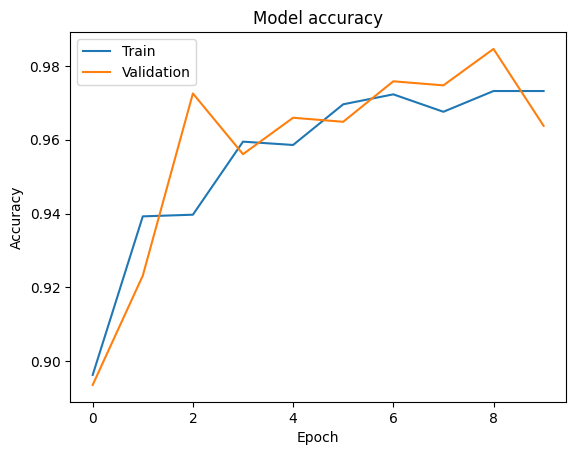

In [17]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

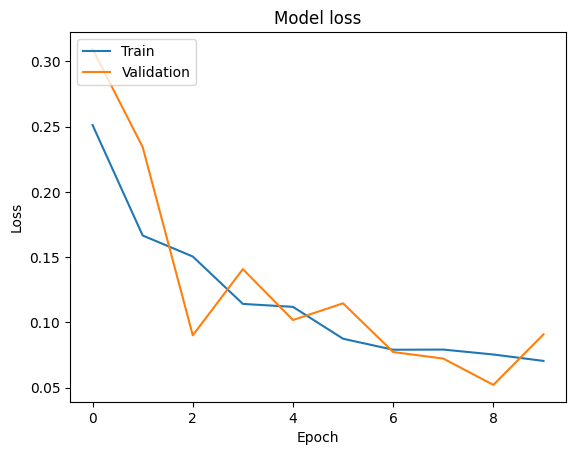

In [18]:
# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [23]:
#Predict the Test Data
predictions = model.predict(test_data)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


29/29 ━━━━━━━━━━━━━━━━━━━━ 16s 549ms/step


29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 425ms/step


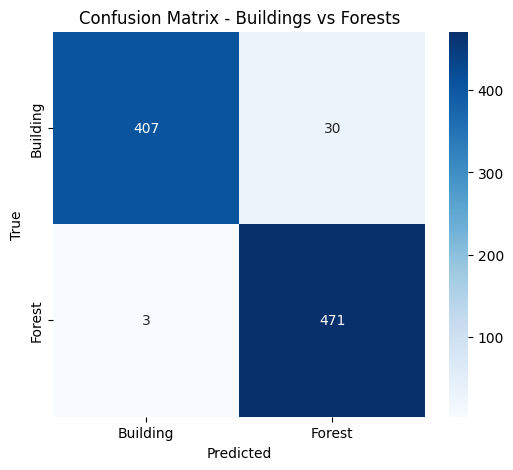

Classification Report (Buildings vs Forests):
              precision    recall  f1-score   support

    Building       0.99      0.93      0.96       437
      Forest       0.94      0.99      0.97       474

    accuracy                           0.96       911
   macro avg       0.97      0.96      0.96       911
weighted avg       0.97      0.96      0.96       911



In [24]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
# Get true labels from the test generator
true_labels = test_data.classes

# Get predicted probabilities from your trained model
pred_probs = model.predict(test_data)

# Convert probabilities to class predictions (0 = Building, 1 = Forest)
predicted_labels = (pred_probs > 0.5).astype(int).reshape(-1)

# Confusion Matrix
cm = confusion_matrix(true_labels, predicted_labels)

#Plot Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Building','Forest'],
            yticklabels=['Building','Forest'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Buildings vs Forests')
plt.show()



# Classification Report
print("Classification Report (Buildings vs Forests):")
print(classification_report(true_labels, predicted_labels,
                            target_names=['Building','Forest']))